### Import libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Retreive data from UCI dataset

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ["age", "work-class", "fnlwgt", "education", "education-num","marital-status", "occupation", "relationship",
           "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]
data = pd.read_csv(url, names=columns, sep=',', na_values='?', skipinitialspace=True)

### Display 20 random samples of the dataset

In [ ]:
data.sample(20)

,age,work-class,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
17114,40,Private,174515,HS-grad,9,Widowed,Machine-op-inspct,Unmarried,White,Female,0,0,40,United-States,<=50K
5315,32,Private,183356,HS-grad,9,Never-married,Craft-repair,Own-child,White,Male,0,0,40,United-States,<=50K
29559,44,Private,110908,Assoc-voc,11,Married-civ-spouse,Transport-moving,Wife,White,Female,0,0,25,United-States,<=50K
12723,46,Self-emp-not-inc,103538,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,65,United-States,>50K
24863,61,Private,34632,12th,8,Married-spouse-absent,Prof-specialty,Not-in-family,White,Male,0,0,40,United-States,<=50K
20234,60,Self-emp-not-inc,218085,HS-grad,9,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,50,United-States,<=50K
2903,42,Private,200574,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,<=50K
6087,19,State-gov,112432,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,0,0,10,United-States,<=50K
25967,43,Private,167265,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,84,United-States,>50K
27556,59,Self-emp-not-inc,98418,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,20,United-States,<=50K


### Check how much are the missing data

In [ ]:
print("Missing value count occupation: ", data['occupation'].isnull().sum())
print("Missing value count work-class: ", data['work-class'].isnull().sum())
print("Missing value count native-country: ", data['native-country'].isnull().sum())

Missing value count occupation:  1843
Missing value count work-class:  1836
Missing value count native-country:  583


([<matplotlib.patches.Wedge at 0x7d2ecef496f0>,
 [Text(-1.0740830340664032, 0.23737235713264912, ''),
  Text(1.0740830118419944, -0.2373724576955599, '')],
 [Text(-0.5858634731271289, 0.12947583116326314, '93%'),
  Text(0.5858634610047242, -0.12947588601575993, '7%')])

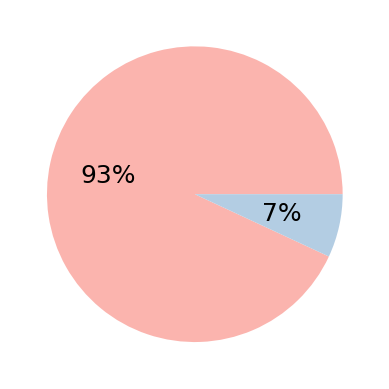

In [ ]:
data_nona = data.dropna().drop_duplicates()

plt.pie([
    data.shape[0],
    data.shape[0] - data_nona.shape[0]
],
autopct='%.0f%%', textprops={'size': '18'},
colors=plt.colormaps["Pastel1"]([0, 1]))
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Use only rows that don't have missing values or duplicated values.

In [ ]:
data = data_nona

### Descriptive Statistics

In [ ]:
data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,30139.000000,3.013900e+04,30139.000000,30139.000000,30139.000000,30139.000000
mean,38.441720,1.897950e+05,10.122532,1092.841202,88.439928,40.934703
std,13.131426,1.056586e+05,2.548738,7409.110596,404.445239,11.978753
min,17.000000,1.376900e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176275e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.784170e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376045e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### Age frequency distribution

<Axes: ylabel='Frequency'>

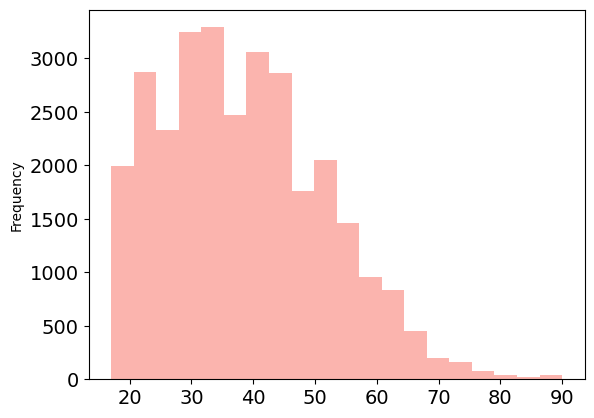

In [ ]:
data['age'].plot(kind='hist', bins=20, colormap='Pastel1', fontsize=14)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Hours-per-week frequency distribution

<Axes: ylabel='Frequency'>

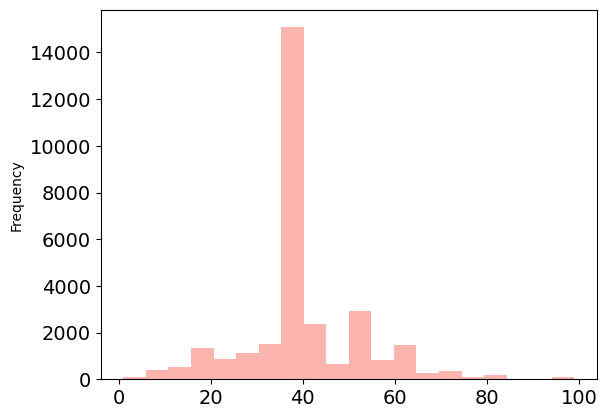

In [ ]:
data['hours-per-week'].plot(kind='hist', bins=20, colormap='Pastel1', fontsize=14)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Education frequency distribution

<Axes: ylabel='Frequency'>

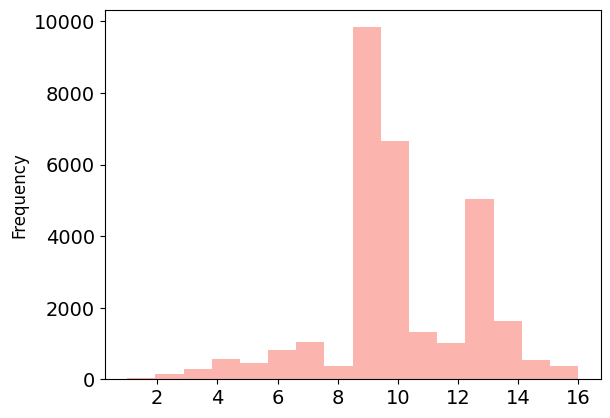

In [ ]:
data['education-num'].plot(kind='hist', bins=16, colormap='Pastel1', fontsize=14)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### US native / Other countries ratio

([<matplotlib.patches.Wedge at 0x7ece90d776d0>,
 [Text(-1.0582376915662706, 0.30022156509566617, ''),
  Text(1.058237684539077, -0.30022158986550723, '')],
 [Text(-0.5772205590361474, 0.1637572173249088, '91%'),
  Text(0.5772205552031329, -0.16375723083573118, '9%')])

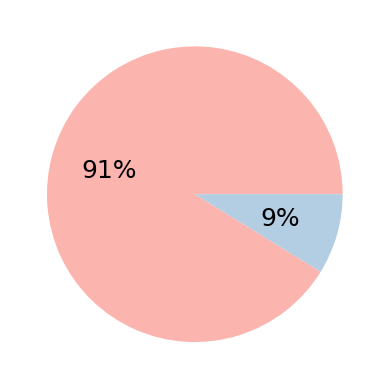

In [ ]:
count_us = sum(data['native-country'] == 'United-States')

plt.pie([
    count_us,
    data.shape[0] - count_us
],
autopct='%.0f%%', textprops={'size': '18'},
colors=plt.colormaps["Pastel1"]([0, 1]))
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### How many native to Thailand in the dataset

In [ ]:
sum(data['native-country'] == 'Thailand')

17

In [ ]:
sum(data['native-country'] == 'Thailand') / data.shape[0] * 100

0.05640532200802946

### Top 3 Education Countries

In [ ]:
nc_mean_eds = []
for nc in data['native-country'].unique():
    mean_ed = data.loc[data['native-country'] == nc]['education-num'].mean()
    nc_mean_eds.append((nc, mean_ed))
print('Top 3 Native Countries with Highest Education :')
for nc, mean_ed in sorted(nc_mean_eds, key=lambda x: x[1], reverse=True)[:3]:
    print(nc, mean_ed)
print()
print('Top 3 Native Countries with Lowest Education :')
for nc, mean_ed in sorted(nc_mean_eds, key=lambda x: x[1], reverse=False)[:3]:
    print(nc, mean_ed)

Top 3 Native Countries with Highest Education :
Taiwan 13.476190476190476
Iran 12.452380952380953
India 12.43

Top 3 Native Countries with Lowest Education :
Mexico 6.145214521452146
Guatemala 6.19672131147541
Portugal 6.852941176470588


In [ ]:
for nc in ['Taiwan', 'Iran', 'India']:
    quantile = data.loc[data['native-country'] == nc]['education-num'].quantile(.25)
    print(nc, quantile)
print()
for nc in ['Mexico', 'Guatemala', 'Portugal']:
    quantile = data.loc[data['native-country'] == nc]['education-num'].quantile(.75)
    print(nc, quantile)

Taiwan 13.0
Iran 10.0
India 10.0

Mexico 9.0
Guatemala 9.0
Portugal 9.0


### <=50K/>50K income ratio

([<matplotlib.patches.Wedge at 0x7ece90dda9b0>,
 [Text(-0.7801449305292097, 0.7754830026309891, ''),
  Text(0.7801449305292096, -0.7754830026309892, '')],
 [Text(-0.425533598470478, 0.4229907287078122, '75%'),
  Text(0.42553359847047795, -0.42299072870781224, '25%')])

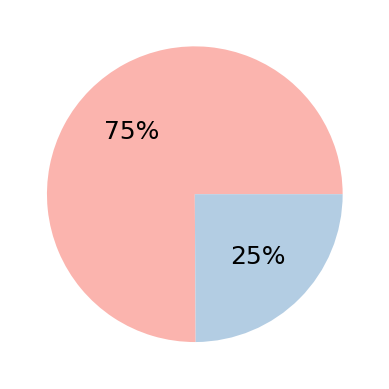

In [ ]:
plt.pie([
    sum(data['income'] == '<=50K'),
    sum(data['income'] == '>50K')
],
autopct='%.0f%%', textprops={'size': '18'},
colors=plt.colormaps["Pastel1"]([0, 1]))
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Age vs Relationship

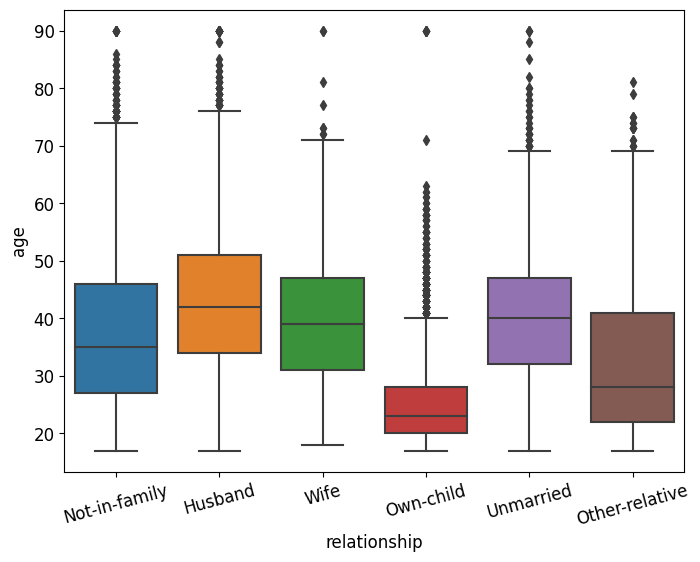

In [ ]:
plt.figure(figsize=(8,6))
plt.rc('font', size=12)
plt.xticks(rotation=15)
sns.boxplot(x="relationship",y="age", data=data)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Age vs Marital-Status

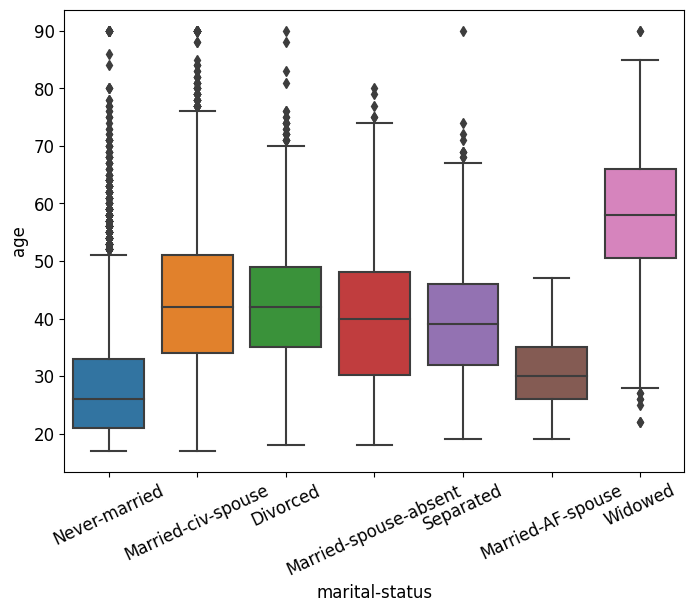

In [ ]:
plt.figure(figsize=(8,6))
plt.rc('font', size=12)
plt.xticks(rotation=25)
sns.boxplot(x="marital-status",y="age", data=data)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Age vs Occuapation

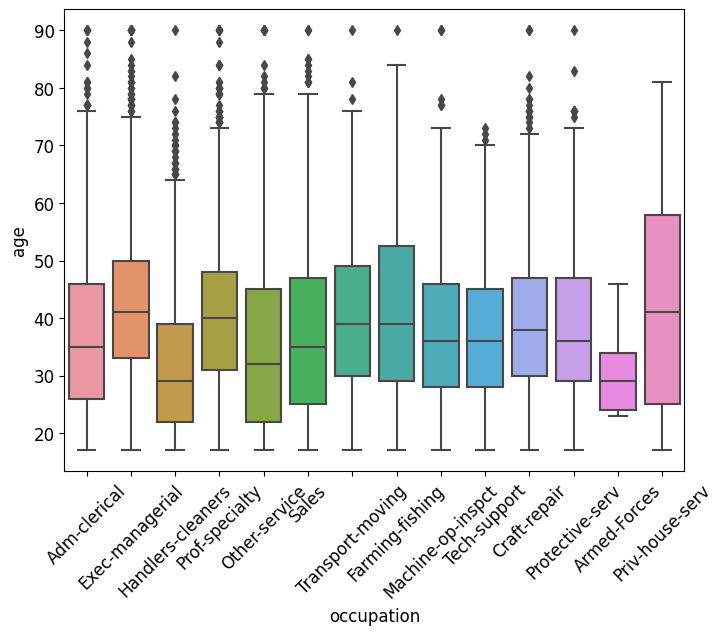

In [ ]:
plt.figure(figsize=(8,6))
plt.rc('font', size=12)
plt.xticks(rotation=45)
sns.boxplot(x="occupation",y="age", data=data)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Age vs Education

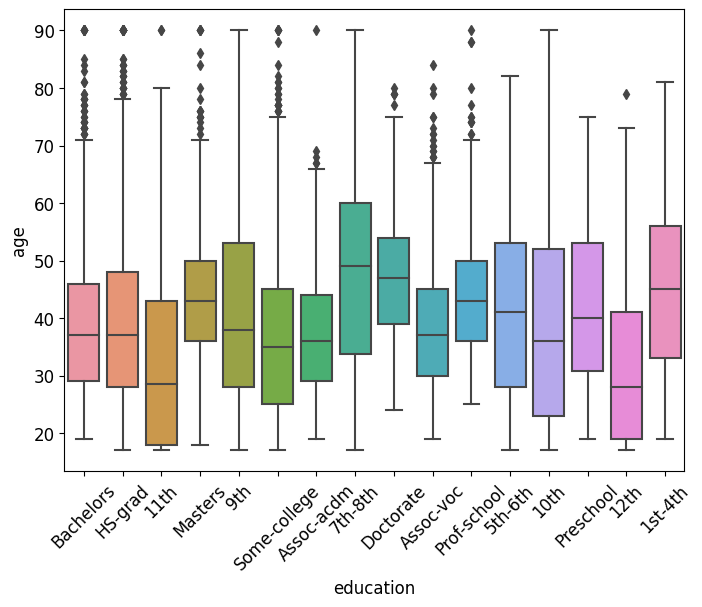

In [ ]:
plt.figure(figsize=(8,6))
plt.rc('font', size=12)
plt.xticks(rotation=45)
sns.boxplot(x="education",y="age", data=data)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Hours-Per-Week vs Occupation/Sex

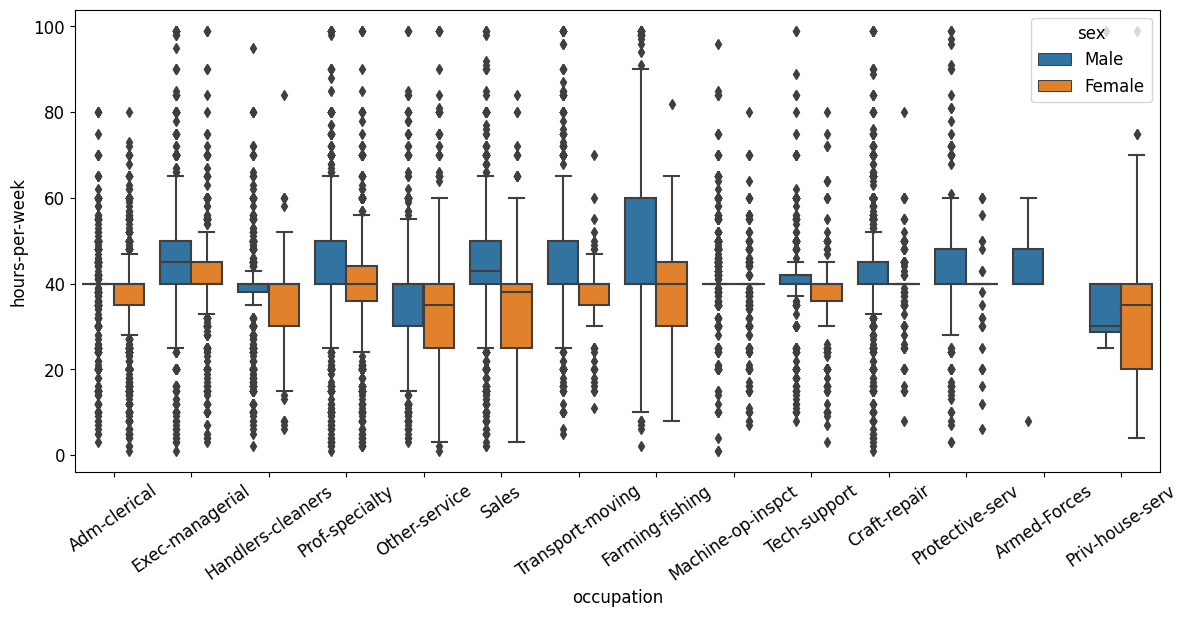

In [ ]:
plt.figure(figsize=(14,6))
plt.rc('font', size=12)
plt.xticks(rotation=35)
sns.boxplot(x="occupation",y="hours-per-week", hue='sex', data=data)
plt.legend(loc='upper right', title='sex')
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Pearson Correlation of Numerical Features

<ipython-input-29-57fccdc3e8bd>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = data.corr()


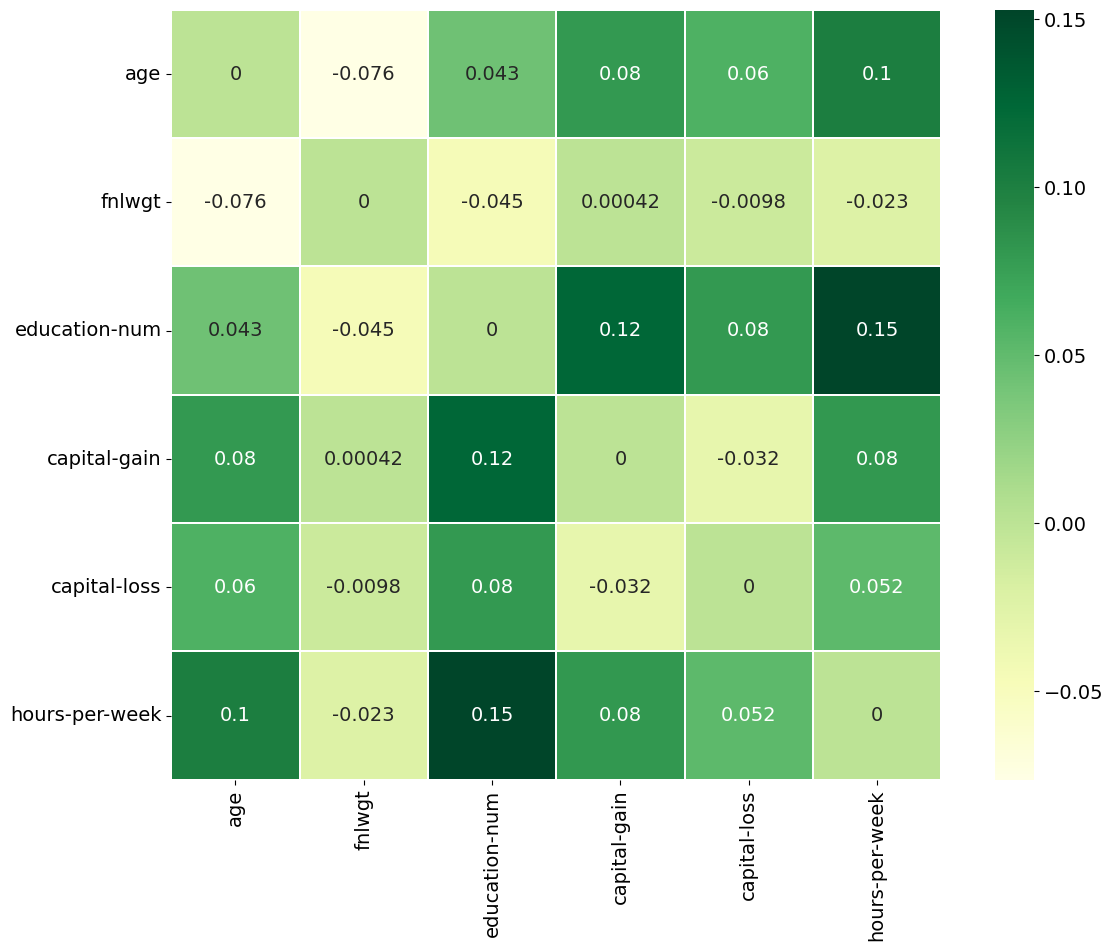

In [ ]:
# Compute the correlation matrix
corr = data.corr()

for feature in ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']:
    corr[feature][feature] = 0.0

f, ax = plt.subplots(figsize=(14, 10))
# plt.rc('font', size=14)
_ = sns.heatmap(corr, cmap="YlGn", square=True, ax=ax, annot=True, linewidth = 0.1)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Race frequency distribution

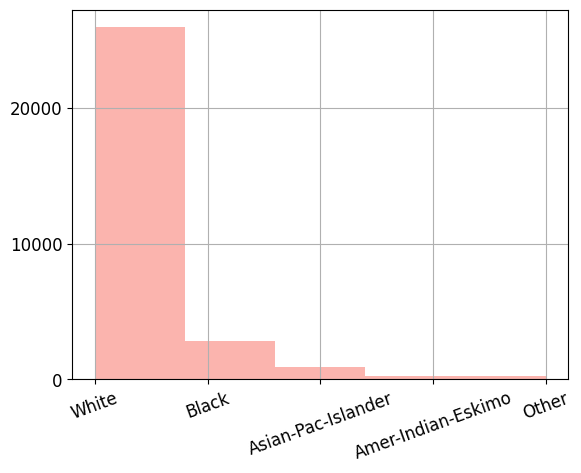

In [ ]:
data['race'].hist(xrot=20, color=plt.colormaps["Pastel1"]([0]), xlabelsize=12, ylabelsize=12, bins=5)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Sex frequency distribution

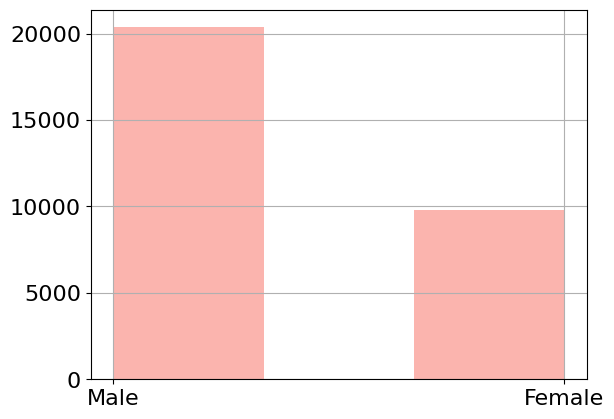

In [ ]:
#f, ax = plt.subplots(figsize=(2, 6))
# plt.rc('font', size=24)

data['sex'].hist(color=plt.colormaps["Pastel1"]([0]), xlabelsize=16, ylabelsize=16, bins=3)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Income-sex crosstab heatmap

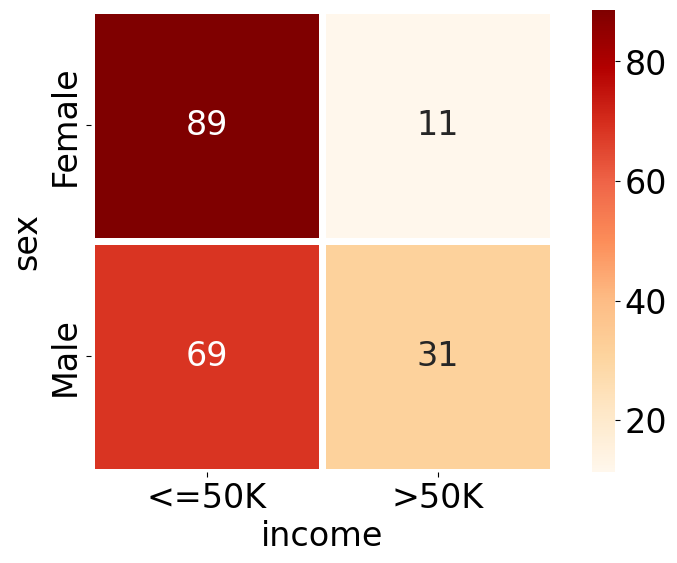

In [ ]:
sex_income_cross = pd.crosstab(data['sex'], data['income'], normalize='index')

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 6))

# plt.rcParams.update({'font.size': 25})
plt.rc('font', size=24)

# Draw the heatmap
_ = sns.heatmap(sex_income_cross*100, cmap="OrRd", square=True, ax=ax, annot=True, linewidth=5)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')

### Occupation-Education crosstab heatmap

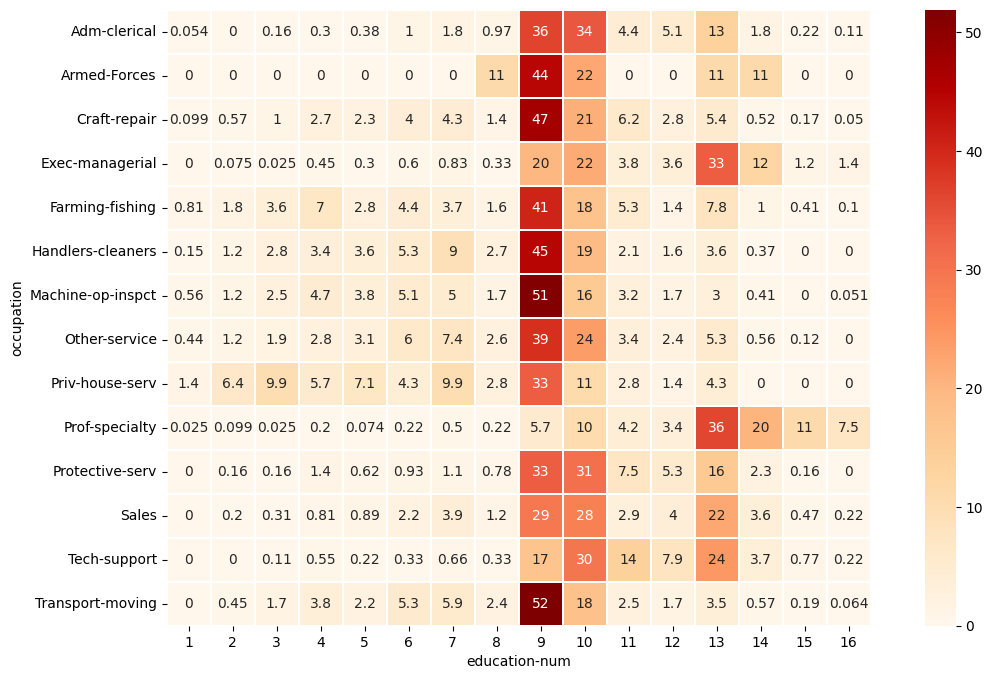

In [ ]:
oc_ed_cross = pd.crosstab(data['occupation'], data['education-num'], normalize='index')

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(14, 8))

# plt.rcParams.update({'font.size': 10})

# Draw the heatmap
_ = sns.heatmap(oc_ed_cross*100, cmap="OrRd", square=True, ax=ax, annot=True, linewidth=0.1)
# plt.savefig('fig.png', transparent=True, bbox_inches='tight')